## 5. Quantum Data Encoding
---
__Amplitude Enconding (Κωδικοποίηση Πλάτους)__
Αντί να χρειαστούμε 16qbits για 16 χαρακτηριστικά, κωδικοποιούμε την πληροφορια στα πλάτη πιθανότητας της κβαντικής κατάστασης. Έτσι, μπορούμε να χωρέσουμε $2^\nu$ χαρακτηριστικά σε ν qbits. Για βα φορτωθούν τα δεδομένα σε μια κβαντική κατάσταση θα, το διάνυσμα κάθε εγγραφής πρέπει να κανονικοποιηθεί, ώστε το άρθισμα των τετραγώνων των στοιχείων του να ισούτε με 1.

### 5.1 Σχεδιασμός Κβαντικού Μοντέλου (Amplitude VQC Architecture)
---
 Εδώ συνθέτουνε την τλική αρχιτεκτονική του μοντέλου μας αποκλειστικά για Amplitude encoding 4 qubit.
 **Feature Map** (RowFeatureVector): Ένα εξειδικευμένο κύκλωμα του Qiskit που δέχεται 16 χαρακτηριστικά και τα μετατρέπει αυτόματα σε μια κβαντική κατάσταση 4 Qubit.
 **Ansatz** (RealAmplitudes): Το παραμετρικό κυκλωμα που λειτουργεί ως το "νευρωνικό δίκτυο" και θα εκπαιδευτεί. Επειδή έχουμε μόνο 4qubits, θα του δώσουμε μεγαλύτερο βάθος για να έχει περισσότερες παραμέτρους και να μπορεί να μάθει πιο σύνθετα μοτίβα στις επιθέσεις.

### 5.2 Επιλογή Optimizer: Γιατί COBYLA;
---
Για να εκπαιδεύσουμε το κβαντικό μας μοντέλο (VQC), χρειαζόμαστε έναν αλγόριθμο βελτιστοποίησης (Optimizer). Ο ρόλος του είναι να βρίσκει τις ιδανικές τιμές για τις άγνωστες γωνίες (τα εκπαιδεύσιμα βάρη $\theta$) του Ansatz, ώστε να ελαχιστοποιείται το σφάλμα (loss) στις προβλέψεις του μοντέλου.

Στο συγκεκριμένο αρχιτεκτονικό σχήμα (Amplitude Encoding), επιλέγουμε τον **COBYLA** (Constrained Optimization BY Linear Approximations) για έναν πολύ συγκεκριμένο, τεχνικό λόγο:

1. **Η "Παγίδα" των Παραγώγων (Gradients):** Οι περισσότεροι κλασικοί optimizers (όπως ο Adam στα Νευρωνικά Δίκτυα) βασίζονται στον υπολογισμό παραγώγων (gradient descent). Χρησιμοποιούν δηλαδή την κλίση της συνάρτησης σφάλματος για να καταλάβουν προς τα πού πρέπει να αλλάξουν τα βάρη. Ωστόσο, η συνάρτηση `raw_feature_vector` που χρησιμοποιούμε, βασίζεται στην κβαντική εντολή `initialize()`. Αυτή η εντολή δεν υποστηρίζει αναλυτική παραγώγιση στο Qiskit. Αν χρησιμοποιούσαμε gradient-based optimizer, η εκπαίδευση θα αποτύγχανε.
2. **Η Λύση του COBYLA (Gradient-Free Optimization):** Ο COBYLA ανήκει στην κατηγορία των *gradient-free* αλγορίθμων, που σημαίνει ότι δεν χρειάζεται να υπολογίσει παραγώγους. 
3. **Πώς λειτουργεί (Η μέθοδος Simplex):** Αντί για παραγώγους, ο COBYLA χτίζει γραμμικές προσεγγίσεις. Δημιουργεί ένα νοητό γεωμετρικό σχήμα (Simplex) στον χώρο των βαρών. Αξιολογεί το σφάλμα στις κορυφές αυτού του σχήματος (κάνοντας δοκιμαστικές εκτελέσεις του κυκλώματος) και "μαντεύει" προς ποια κατεύθυνση βρίσκεται το μικρότερο λάθος. Στη συνέχεια, "μετακινεί" το σχήμα του προς τα εκεί, ενημερώνοντας σταδιακά τα βάρη $\theta$.

Αυτή η μαθηματική προσέγγιση καθιστά τον COBYLA την πιο αξιόπιστη και μονόδρομη επιλογή για κυκλώματα που κάνουν απευθείας State Preparation.

In [ ]:
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

# Scikit-Learn
from sklearn.preprocessing import normalize
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Qiskit & Qiskit Machine Learning
from qiskit import QuantumCircuit
from qiskit.circuit.library import StatePreparation, RealAmplitudes
from qiskit_machine_learning.circuit.library import raw_feature_vector
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA

# 0. ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ ΑΠΟ ΤΟ ΠΡΟΗΓΟΥΜΕΝΟ NOTEBOOK
file_path = os.path.expanduser('~/Documents/projects/Quantum-IDS-NSLKDD/npz/nslkdd_pca_ready.npz')

# 0. ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ 
print(f"--- 0. Άνοιγμα δεδομένων από: {file_path} ---")

# Αν βγάλει error εδώ, σημαίνει ότι το αρχείο δεν σώθηκε ποτέ στον κεντρικό φάκελο!
data = np.load(file_path, allow_pickle=True)

# Ξεπακετάρισμα στις μεταβλητές που περιμένει ο υπόλοιπος κώδικας
xTrain_pca = data['xTrain_pca']
xTest_pca = data['xTest_pca']
yTrain = data['yTrain']
yTest = data['yTest']

print(f"✅ Τα δεδομένα φορτώθηκαν επιτυχώς!")
print(f"Μέγεθος xTrain_pca: {xTrain_pca.shape}")

# ==========================================
# 1. ΠΡΟΕΤΟΙΜΑΣΙΑ ΔΕΔΟΜΕΝΩΝ (DATA PREP)
# ==========================================

print("--- 1. Κανονικοποίηση (L2 Norm) & Binarization ---")

# Κανονικοποίηση
xTrain_norm = normalize(xTrain_pca, norm='l2', axis=1)
xTest_norm = normalize(xTest_pca, norm='l2', axis=1)

# Binarization
yTrain_bin = (yTrain != 'normal').astype(int)
yTest_bin = (yTest != 'normal').astype(int)

print("--- 1. Κανονικοποίηση (L2 Norm) & Binarization ---")
print(f"L2 Norm της πρώτης εγγραφής μετά την κανονικοποίηση: {l2_norm_check:.4f}")
yTrain_bin = (yTrain != 'normal').astype(int)
yTest_bin = (yTest != 'normal').astype(int)
xTrain_full = xTrain_norm
yTrain_full = yTrain_bin
xTest_full = xTest_norm
yTest_full = yTest_bin
# ==========================================
# 2. ΟΠΤΙΚΟΠΟΙΗΣΗ ΚΥΚΛΩΜΑΤΩΝ
# ==========================================
print("\n--- 2. Οπτικοποίηση State Preparation ---")
num_qubits = 4
sample_data = xTrain_full[0]  
state_prep = StatePreparation(sample_data)
qc = QuantumCircuit(num_qubits, name="Amplitude encoding")
qc.append(state_prep, range(num_qubits))
display(qc.draw(output='mpl', style='clifford'))

print("\n--- 3. Δομή VQC (Feature Map + Ansatz) ---")
feature_vector_circuit = raw_feature_vector(feature_dimension=16)
# Χρησιμοποιούμε reps=5 (όπως είχαμε πει για το βαρύ σενάριο)
ansatz_amp = RealAmplitudes(num_qubits=4, reps=5)
vqc_amp = feature_vector_circuit.compose(ansatz_amp)

print(f'Απαιτούμενα Qubits: {vqc_amp.num_qubits}')
print(f'Αριθμός παραμέτρων ansatz: {vqc_amp.num_parameters}')
display(vqc_amp.draw(output='mpl', style='clifford'))

# ==========================================
# 3. ΣΤΗΣΙΜΟ ΜΟΝΤΕΛΟΥ (VQC)
# ==========================================
optimizer = COBYLA(maxiter=500)

objective_func_vals = []
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    objective_func_vals.append(obj_func_eval)
    plt.figure(figsize=(8, 5))
    plt.title("Τελική Εκπαίδευση VQC (Full Dataset - Reps:5)")
    plt.xlabel("Επανάληψη (Iteration)")
    plt.ylabel("Σφάλμα (Objective Function Loss)")
    plt.plot(range(len(objective_func_vals)), objective_func_vals, color='purple', linewidth=2)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

vqc_amp_model_final = VQC(
    feature_map=feature_vector_circuit,
    ansatz=ansatz_amp,
    optimizer=optimizer,
    callback=callback_graph
)

# ==========================================
# 4. ΕΚΠΑΙΔΕΥΣΗ (TRAINING)
# ==========================================
print(f"\nΞεκινάει η ΚΑΝΟΝΙΚΗ εκπαίδευση σε {len(xTrain_full)} δείγματα...")
start_time = time.time()

# Εδώ είναι το κρίσιμο σημείο που θα "σκάσει" το Error αν υπάρχει θέμα!
vqc_amp_model_final.fit(xTrain_full, yTrain_full)

end_time = time.time()
print(f"\nΗ εκπαίδευση ολοκληρώθηκε επιτυχώς σε {(end_time - start_time)/60:.2f} λεπτά!")

# ==========================================
# 5. ΑΞΙΟΛΟΓΗΣΗ & ΑΠΟΘΗΚΕΥΣΗ
# ==========================================
print("\nΤο κβαντικό μοντέλο εξετάζει το FULL Test Set...")
y_pred_full = vqc_amp_model_final.predict(xTest_full)
test_score_full = vqc_amp_model_final.score(xTest_full, yTest_full)

print(f"\nΣυνολική Ακρίβεια (Accuracy): {test_score_full * 100:.2f}%\n")
print("--- Αναλυτική Αναφορά (Classification Report) ---")
print(classification_report(yTest_full, y_pred_full, target_names=["Normal (0)", "Attack (1)"]))

# Τελικό Confusion Matrix
cm = confusion_matrix(yTest_full, y_pred_full)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Attack"])
disp.plot(cmap='Purples')
plt.title("Τελικός Πίνακας Σύγχυσης (Full Test Set)")
plt.show()

#save model 
save_dir = os.path.expanduser('~/Documents/projects/Quantum-IDS-NSLKDD/models')
os.makedirs(save_dir, exist_ok=True)
model_path = os.path.join(save_dir, 'vqc_amplitude_model.model')
vqc_amp_model_final.save(model_path)
print(f"Το μοντέλο αποθηκεύτηκε με ασφάλεια στο απόλυτο μονοπάτι:\n{model_path}")

--- 1. Φόρτωση του Εκπαιδευμένου Μοντέλου ---
Το μοντέλο φορτώθηκε επιτυχώς!

--- 1.5. Φόρτωση των Δεδομένων (NPZ) ---
Τα δεδομένα φορτώθηκαν επιτυχώς!

--- 2. Εκτέλεση Προβλέψεων (Inference) στο Test Set ---


/tmp/ipykernel_133705/2441711787.py:9: DeprecationWarning: SerializableModelMixin.load() is deprecated. as of qiskit-machine-learning 0.9.0 and will be removed no sooner than 4 months after the release date. Use the from_dill() classmethod instead.
  loaded_vqc = VQC.load(file_path)


Οι προβλέψεις ολοκληρώθηκαν!

--- 3. Αναλυτικές Μετρικές (Classification Report) ---
              precision    recall  f1-score   support

  Normal (0)       0.90      0.87      0.89      2690
  Attack (1)       0.86      0.89      0.88      2347

    accuracy                           0.88      5037
   macro avg       0.88      0.88      0.88      5037
weighted avg       0.88      0.88      0.88      5037


--- 4. Οπτικοποίηση Πίνακα Σύγχυσης (Confusion Matrix) ---


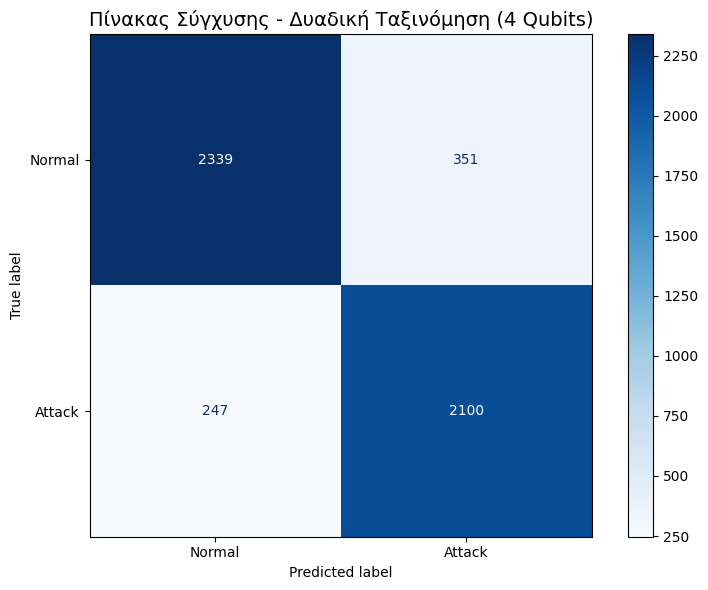

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from qiskit_machine_learning.algorithms import VQC
import os

print("--- 1. Φόρτωση του Εκπαιδευμένου Μοντέλου ---")
file_path = os.path.expanduser('~/Documents/projects/Quantum-IDS-NSLKDD/models/vqc_amplitude_model.model')
loaded_vqc = VQC.load(file_path) 
print("Το μοντέλο φορτώθηκε επιτυχώς!")

print("\n--- 1.5. Φόρτωση των Δεδομένων (NPZ) ---")
data_path = os.path.expanduser('~/Documents/projects/Quantum-IDS-NSLKDD/npz/nslkdd_pca_ready.npz')

# Ανοίγουμε το αρχείο .npz
data = np.load(data_path)

# Τραβάμε τα arrays από μέσα (βεβαιώσου ότι τα ονόματα των keys είναι σωστά 
# με βάση το πώς τα είχες αποθηκεύσει στο προηγούμενο notebook)
xTest_norm = data['xTest_norm']
yTest_bin = data['yTest_bin']

print("Τα δεδομένα φορτώθηκαν επιτυχώς!")

print("\n--- 2. Εκτέλεση Προβλέψεων (Inference) στο Test Set ---")
y_pred_binary = loaded_vqc.predict(xTest_norm) 
print("Οι προβλέψεις ολοκληρώθηκαν!")

print("\n--- 3. Αναλυτικές Μετρικές (Classification Report) ---")
report = classification_report(yTest_bin, y_pred_binary, target_names=['Normal (0)', 'Attack (1)'])
print(report)

print("\n--- 4. Οπτικοποίηση Πίνακα Σύγχυσης (Confusion Matrix) ---")
cm = confusion_matrix(yTest_bin, y_pred_binary)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])

disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title("Πίνακας Σύγχυσης - Δυαδική Ταξινόμηση (4 Qubits)", fontsize=14)
plt.tight_layout()
plt.show()